In [1]:
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import torch
import torch.nn as nn
import torch.optim as optim

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import LearningRateScheduler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from google.colab import drive
from torch.utils.data import TensorDataset, DataLoader

# Keeping the seed fixed so the runs stay reproducible
SEED = 21
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("PyTorch version:", torch.__version__)

TensorFlow version: 2.19.0
PyTorch version: 2.10.0+cpu


In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Loading the tabular dataset from the student wellness dataset
tabular_base_path = "/content/drive/MyDrive/student_wellness_multimodal_dataset/student_wellness_multimodal_dataset/tabular"

train_tabular_path = os.path.join(tabular_base_path, "train.csv")
test_tabular_path = os.path.join(tabular_base_path, "test.csv")

train_tabular_df = pd.read_csv(train_tabular_path)
test_tabular_df = pd.read_csv(test_tabular_path)

print("Train shape:", train_tabular_df.shape)
print("Test shape:", test_tabular_df.shape)

Train shape: (240, 13)
Test shape: (80, 13)


In [4]:
# Turning text labels into numeric classes
label_to_index = {
    label: idx for idx, label in enumerate(sorted(train_tabular_df["label"].unique()))
}

index_to_label = {idx: label for label, idx in label_to_index.items()}

train_tabular_df["label_id"] = train_tabular_df["label"].map(label_to_index)
test_tabular_df["label_id"] = test_tabular_df["label"].map(label_to_index)

print(label_to_index)

{'critical_risk': 0, 'high_risk': 1, 'low_risk': 2, 'moderate_risk': 3}


In [5]:
# Keeping only numeric columns for modeling
excluded_columns = ["label", "label_id"]

numeric_feature_columns = [
    col for col in train_tabular_df.columns
    if col not in excluded_columns and pd.api.types.is_numeric_dtype(train_tabular_df[col])
]

X_train_full = train_tabular_df[numeric_feature_columns].values
y_train_full = train_tabular_df["label_id"].values

X_test = test_tabular_df[numeric_feature_columns].values
y_test = test_tabular_df["label_id"].values

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (192, 10)
Validation shape: (48, 10)
Test shape: (80, 10)


In [6]:
# This is a simple baseline model that I will reuse for the TensorFlow scheduler experiments
def build_tf_scheduler_model(input_dim, learning_rate=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(len(label_to_index), activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [7]:
# A baseline run with a fixed learning rate
tf_baseline_model = build_tf_scheduler_model(X_train.shape[1], learning_rate=1e-3)

history_tf_baseline = tf_baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=16,
    verbose=0
)

tf_baseline_test_loss, tf_baseline_test_acc = tf_baseline_model.evaluate(X_test, y_test, verbose=0)
print("TF Baseline Test Accuracy:", round(tf_baseline_test_acc, 4))

TF Baseline Test Accuracy: 0.875


In [8]:
# Step decay scheduler: the learning rate drops after a few epochs
def step_decay_schedule(epoch, lr):
    if epoch < 5:
        return 1e-3
    elif epoch < 10:
        return 5e-4
    else:
        return 1e-4

In [9]:
# Exponential decay scheduler: the learning rate keeps shrinking gradually
def exponential_decay_schedule(epoch, lr):
    initial_lr = 1e-3
    decay_rate = 0.85
    return initial_lr * (decay_rate ** epoch)

In [10]:
# A simple cosine-style schedule for smoother changes in the learning rate
def cosine_decay_schedule(epoch, lr):
    initial_lr = 1e-3
    min_lr = 1e-5
    total_epochs = 15
    cosine_value = 0.5 * (1 + math.cos(math.pi * epoch / total_epochs))
    return min_lr + (initial_lr - min_lr) * cosine_value

In [11]:
# This is a basic one-cycle style schedule where the LR first rises and then falls
def one_cycle_style_schedule(epoch, lr):
    if epoch < 4:
        return 5e-4 + (epoch * 2e-4)
    elif epoch < 10:
        return 1.3e-3 - ((epoch - 4) * 1.5e-4)
    else:
        return 3e-4 * (0.8 ** (epoch - 10))

In [12]:
# Helper function to train one TensorFlow scheduler experiment
def train_tf_scheduler_experiment(schedule_fn, run_name):
    model = build_tf_scheduler_model(X_train.shape[1], learning_rate=1e-3)

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=16,
        verbose=0,
        callbacks=[LearningRateScheduler(schedule_fn)]
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"{run_name} Test Accuracy:", round(test_acc, 4))

    return history, test_acc

In [13]:
# Running the TensorFlow scheduler experiments
history_tf_step, tf_step_acc = train_tf_scheduler_experiment(step_decay_schedule, "Step Decay")
history_tf_exp, tf_exp_acc = train_tf_scheduler_experiment(exponential_decay_schedule, "Exponential Decay")
history_tf_cosine, tf_cosine_acc = train_tf_scheduler_experiment(cosine_decay_schedule, "Cosine Decay")
history_tf_onecycle, tf_onecycle_acc = train_tf_scheduler_experiment(one_cycle_style_schedule, "One-Cycle Style")

Step Decay Test Accuracy: 0.725
Exponential Decay Test Accuracy: 0.7
Cosine Decay Test Accuracy: 0.8125
One-Cycle Style Test Accuracy: 0.8375


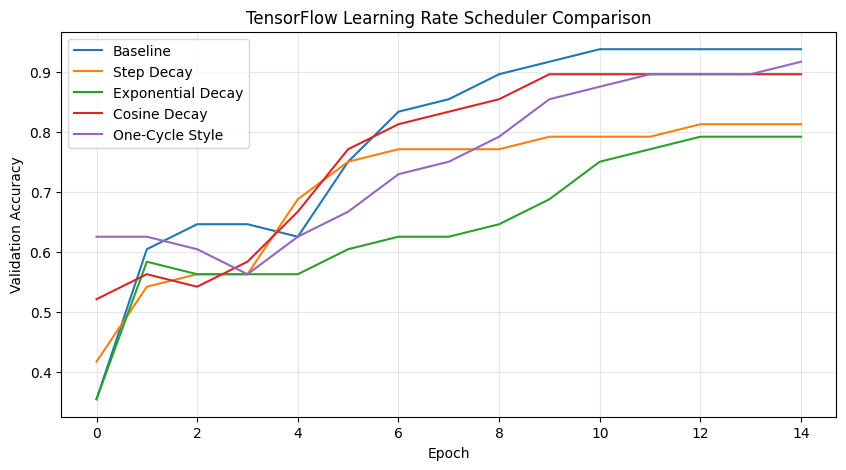

In [14]:
# Comparing the TensorFlow validation accuracy across scheduler experiments
plt.figure(figsize=(10, 5))
plt.plot(history_tf_baseline.history["val_accuracy"], label="Baseline")
plt.plot(history_tf_step.history["val_accuracy"], label="Step Decay")
plt.plot(history_tf_exp.history["val_accuracy"], label="Exponential Decay")
plt.plot(history_tf_cosine.history["val_accuracy"], label="Cosine Decay")
plt.plot(history_tf_onecycle.history["val_accuracy"], label="One-Cycle Style")
plt.title("TensorFlow Learning Rate Scheduler Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [15]:
# Preparing PyTorch datasets and loaders
batch_size = 16

X_train_torch = torch.tensor(X_train, dtype=torch.float32)
y_train_torch = torch.tensor(y_train, dtype=torch.long)

X_val_torch = torch.tensor(X_val, dtype=torch.float32)
y_val_torch = torch.tensor(y_val, dtype=torch.long)

X_test_torch = torch.tensor(X_test, dtype=torch.float32)
y_test_torch = torch.tensor(y_test, dtype=torch.long)

torch_train_loader = DataLoader(TensorDataset(X_train_torch, y_train_torch), batch_size=batch_size, shuffle=True)
torch_val_loader = DataLoader(TensorDataset(X_val_torch, y_val_torch), batch_size=batch_size, shuffle=False)
torch_test_loader = DataLoader(TensorDataset(X_test_torch, y_test_torch), batch_size=batch_size, shuffle=False)

In [16]:
# This is a simple PyTorch model for optimizer comparison
class TorchSchedulerNet(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [17]:
# Helper function to train one PyTorch optimizer experiment
def train_torch_optimizer_experiment(optimizer_name="adam", epochs=15):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = TorchSchedulerNet(X_train.shape[1], len(label_to_index)).to(device)
    loss_fn = nn.CrossEntropyLoss()

    if optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=1e-3)
    elif optimizer_name == "sgd_momentum":
        optimizer = optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)
    elif optimizer_name == "rmsprop":
        optimizer = optim.RMSprop(model.parameters(), lr=1e-3)
    else:
        raise ValueError("Unsupported optimizer name")

    val_acc_history = []

    for epoch in range(epochs):
        model.train()
        for xb, yb in torch_train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for xb, yb in torch_val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb).argmax(dim=1)
                correct += (preds == yb).sum().item()
                total += yb.size(0)

        val_acc = correct / total
        val_acc_history.append(val_acc)

    correct_test = 0
    total_test = 0
    model.eval()
    with torch.no_grad():
        for xb, yb in torch_test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(dim=1)
            correct_test += (preds == yb).sum().item()
            total_test += yb.size(0)

    test_acc = correct_test / total_test
    return val_acc_history, test_acc

In [18]:
# Running the PyTorch optimizer experiments
hist_torch_adam, acc_torch_adam = train_torch_optimizer_experiment("adam")
hist_torch_sgd, acc_torch_sgd = train_torch_optimizer_experiment("sgd_momentum")
hist_torch_rmsprop, acc_torch_rmsprop = train_torch_optimizer_experiment("rmsprop")

print("Torch Adam Test Accuracy:", round(acc_torch_adam, 4))
print("Torch SGD+Momentum Test Accuracy:", round(acc_torch_sgd, 4))
print("Torch RMSprop Test Accuracy:", round(acc_torch_rmsprop, 4))

Torch Adam Test Accuracy: 1.0
Torch SGD+Momentum Test Accuracy: 0.9625
Torch RMSprop Test Accuracy: 0.9875


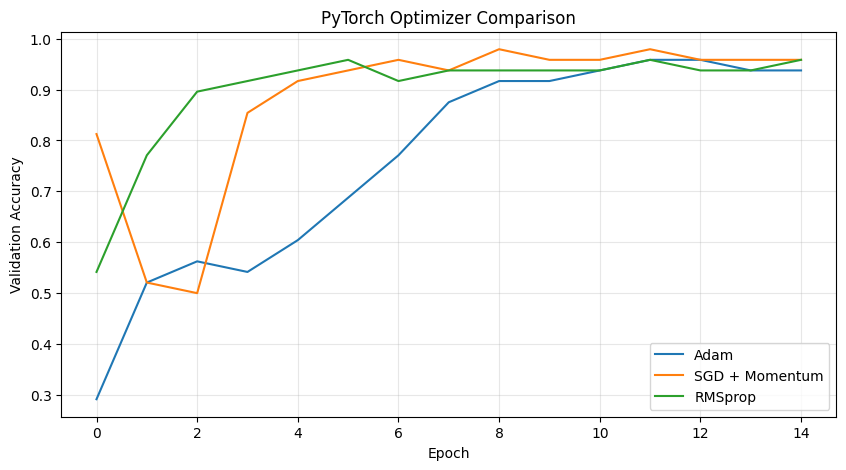

In [19]:
# Comparing the PyTorch optimizer validation curves
plt.figure(figsize=(10, 5))
plt.plot(hist_torch_adam, label="Adam")
plt.plot(hist_torch_sgd, label="SGD + Momentum")
plt.plot(hist_torch_rmsprop, label="RMSprop")
plt.title("PyTorch Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [20]:
# Final summary so the main scheduler and optimizer results are easy to explain
print("TensorFlow Scheduler Results")
print("-" * 45)
print(f"Baseline          : {tf_baseline_test_acc:.4f}")
print(f"Step Decay        : {tf_step_acc:.4f}")
print(f"Exponential Decay : {tf_exp_acc:.4f}")
print(f"Cosine Decay      : {tf_cosine_acc:.4f}")
print(f"One-Cycle Style   : {tf_onecycle_acc:.4f}")

print("\nPyTorch Optimizer Results")
print("-" * 45)
print(f"Adam              : {acc_torch_adam:.4f}")
print(f"SGD + Momentum    : {acc_torch_sgd:.4f}")
print(f"RMSprop           : {acc_torch_rmsprop:.4f}")

TensorFlow Scheduler Results
---------------------------------------------
Baseline          : 0.8750
Step Decay        : 0.7250
Exponential Decay : 0.7000
Cosine Decay      : 0.8125
One-Cycle Style   : 0.8375

PyTorch Optimizer Results
---------------------------------------------
Adam              : 1.0000
SGD + Momentum    : 0.9625
RMSprop           : 0.9875


### Final Observation

In this notebook, I focused on how different learning-rate schedules and optimizer choices affect model training. In TensorFlow, I compared fixed learning rate training against step decay, exponential decay, cosine decay, and a one-cycle style schedule. In PyTorch, I compared different optimizers like Adam, SGD with momentum, and RMSprop. This notebook helped me see that training performance depends not only on the model architecture, but also on how the optimizer and learning rate are managed during training.